# Single-Day Benchmark vs Strategy Return Diagnosis

This notebook computes returns for a selected `trade_day`:
- Benchmark universe (upstream pool, equal-weight)
- Strategy holdings universe (loaded from DB; fallback to latest previous record)

Outputs:
- Same-day gross/net return comparison
- One-figure overlay distribution plot (benchmark vs strategy)
- Benchmark disabled bonds list with reasons


In [25]:
from __future__ import annotations

from datetime import date
from pathlib import Path
import bisect
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 260)


def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "cbond_on" / "cbond_on" / "__init__.py").exists():
            return p / "cbond_on"
        if (p / "cbond_on" / "__init__.py").exists() and (p / "cbond_on" / "core").exists():
            return p
        if p.name == "cbond_on" and (p / "__init__.py").exists() and (p / "core").exists():
            return p
    return start

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if (PROJECT_ROOT / "cbond_on").exists():
    IMPORT_ROOT = PROJECT_ROOT
elif PROJECT_ROOT.name == "cbond_on" and (PROJECT_ROOT / "core").exists():
    IMPORT_ROOT = PROJECT_ROOT.parent
else:
    IMPORT_ROOT = PROJECT_ROOT

if str(IMPORT_ROOT) not in sys.path:
    sys.path.insert(0, str(IMPORT_ROOT))

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"IMPORT_ROOT={IMPORT_ROOT}")
print(f"pandas={pd.__version__}")


PROJECT_ROOT=C:\Users\BaiYang\CBOND_ON\cbond_on
IMPORT_ROOT=C:\Users\BaiYang\CBOND_ON\cbond_on
pandas=3.0.1


In [26]:
try:
    from cbond_on.core.config import load_config_file, parse_date
    from cbond_on.core.trading_days import list_available_trading_days_from_raw
    from cbond_on.core.fees import load_fees_buy_sell_bps
    from cbond_on.infra.io.market_twap import read_twap_daily, read_price_daily
    from cbond_on.infra.data.io import read_table_range
    from cbond_on.infra.backtest.execution import apply_twap_bps, split_cycle_return_by_bridge
    from cbond_on.infra.benchmark.service import load_benchmark_pool_config
    from cbond_on.infra.data.extract import (
        connect_backend,
        get_db_backend,
        normalize_table_name_for_backend,
        resolve_table_target_for_backend,
    )
except ModuleNotFoundError:
    cwd = Path.cwd().resolve()
    added = False
    for p in [cwd, *cwd.parents]:
        c1 = p / "cbond_on" / "cbond_on" / "__init__.py"
        c2 = p / "cbond_on" / "__init__.py"
        if c1.exists():
            cand = p / "cbond_on"
            if str(cand) not in sys.path:
                sys.path.insert(0, str(cand))
            added = True
            break
        if c2.exists() and (p / "cbond_on" / "core").exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            added = True
            break
    if not added:
        raise

    from cbond_on.core.config import load_config_file, parse_date
    from cbond_on.core.trading_days import list_available_trading_days_from_raw
    from cbond_on.core.fees import load_fees_buy_sell_bps
    from cbond_on.infra.io.market_twap import read_twap_daily, read_price_daily
    from cbond_on.infra.data.io import read_table_range
    from cbond_on.infra.backtest.execution import apply_twap_bps, split_cycle_return_by_bridge
    from cbond_on.infra.benchmark.service import load_benchmark_pool_config
    from cbond_on.infra.data.extract import (
        connect_backend,
        get_db_backend,
        normalize_table_name_for_backend,
        resolve_table_target_for_backend,
    )

paths_cfg = load_config_file("data/paths")
RAW_ROOT = paths_cfg["raw_data_root"]
print(f"RAW_ROOT={RAW_ROOT}")


RAW_ROOT=D:/cbond_data_hub/raw_data


In [27]:
# ---- Parameters ----
TRADE_DAY = "2026-04-28"

BUY_TWAP_COL = "twap_1442_1457"
SELL_TWAP_COL = "twap_0930_0945"

# When True: strategy return aggregates by strategy weight.
# When False: strategy summary uses equal-weight average.
USE_STRATEGY_WEIGHT = True

# Export optional CSV files
EXPORT_CSV = False
TOP_N = 40


In [28]:
def normalize_code_series(series: pd.Series) -> pd.Series:
    out = series.astype(str).str.strip()
    out = out.str.replace(r"\.0$", "", regex=True)
    return out


def normalize_pool_code(df: pd.DataFrame) -> pd.Series:
    if "code" in df.columns:
        return normalize_code_series(df["code"])
    if "instrument_code" in df.columns and "exchange_code" in df.columns:
        left = normalize_code_series(df["instrument_code"])
        right = normalize_code_series(df["exchange_code"])
        return left + "." + right
    if "instrument_code" in df.columns:
        return normalize_code_series(df["instrument_code"])
    raise RuntimeError("pool file missing code columns")


def get_next_trade_day(raw_root: str, day: date) -> date:
    all_days = list_available_trading_days_from_raw(raw_root, kind="snapshot", asset="cbond")
    if not all_days:
        raise RuntimeError("no trading calendar found from raw root")
    idx = bisect.bisect_right(all_days, day)
    if idx >= len(all_days):
        raise RuntimeError(f"next trading day missing for {day}")
    return all_days[idx]


def load_benchmark_pool_candidates(raw_root: str, day: date) -> pd.DataFrame:
    cfg = load_benchmark_pool_config()
    pool_df = read_table_range(raw_root, cfg.pool_table, day, day)
    if pool_df.empty:
        raise RuntimeError(f"benchmark pool missing on {day}")
    pool_df = pool_df.copy()
    pool_df["code"] = normalize_pool_code(pool_df)

    if cfg.positive_field in pool_df.columns:
        mask = pd.to_numeric(pool_df[cfg.positive_field], errors="coerce") > cfg.positive_threshold
    elif cfg.positive_fallback_field in pool_df.columns:
        mask = pd.to_numeric(pool_df[cfg.positive_fallback_field], errors="coerce") > cfg.positive_threshold
    else:
        raise RuntimeError("pool missing positive columns")

    out = pool_df.loc[mask, ["code"]].copy()
    out["code"] = normalize_code_series(out["code"])
    out = out.dropna().drop_duplicates().sort_values("code", kind="mergesort").reset_index(drop=True)
    if out.empty:
        raise RuntimeError(f"pool empty after positive filter on {day}")
    return out


def load_strategy_holdings_from_db(target_day: date) -> tuple[pd.DataFrame, date, str, str]:
    live_cfg = load_config_file("live/live")
    out_cfg = dict(live_cfg.get("output", {}))
    table = str(out_cfg.get("db_table", "")).strip()
    if not table:
        raise RuntimeError("live.output.db_table is empty")

    backend = str(out_cfg.get("db_backend") or get_db_backend()).strip().lower() or "postgres"
    db_override, resolved_table = resolve_table_target_for_backend(table, backend)
    table_name = normalize_table_name_for_backend(table, backend, database=db_override)

    sql_latest = f"SELECT MAX(trade_date) AS d FROM {table_name} WHERE trade_date <= %s"
    with connect_backend(backend, database=db_override) as conn:
        latest_df = pd.read_sql(sql_latest, conn, params=[target_day])
    if latest_df.empty or pd.isna(latest_df.loc[0, "d"]):
        raise RuntimeError(f"no strategy holdings in DB on/before {target_day}")

    holdings_day = pd.to_datetime(latest_df.loc[0, "d"]).date()

    sql_rows = (
        f"SELECT instrument_code, exchange_code, trade_date, factor_value, weight, rank "
        f"FROM {table_name} WHERE trade_date = %s"
    )
    with connect_backend(backend, database=db_override) as conn:
        rows = pd.read_sql(sql_rows, conn, params=[holdings_day])

    if rows.empty:
        raise RuntimeError(f"strategy holdings rows empty on db day={holdings_day}")

    rows = rows.copy()
    rows["instrument_code"] = rows["instrument_code"].astype(str).str.strip()
    rows["exchange_code"] = rows["exchange_code"].astype(str).str.strip()
    rows["code"] = rows["instrument_code"] + "." + rows["exchange_code"]
    rows["code"] = normalize_code_series(rows["code"])

    if "weight" not in rows.columns:
        rows["weight"] = np.nan
    rows["weight"] = pd.to_numeric(rows["weight"], errors="coerce")

    return rows[["code", "weight", "factor_value", "rank", "trade_date"]].copy(), holdings_day, table_name, backend


def build_universe_with_reason(base_codes: pd.DataFrame, buy_df: pd.DataFrame, sell_df: pd.DataFrame, bridge_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    b = buy_df[["code", BUY_TWAP_COL]].copy()
    s = sell_df[["code", SELL_TWAP_COL]].copy()
    p = bridge_df[["code", "prev_close_price"]].copy()
    b["code"] = normalize_code_series(b["code"])
    s["code"] = normalize_code_series(s["code"])
    p["code"] = normalize_code_series(p["code"])

    work = base_codes.copy()
    work["code"] = normalize_code_series(work["code"])
    work = work.dropna().drop_duplicates().reset_index(drop=True)

    merged = work.merge(b, on="code", how="left").merge(s, on="code", how="left").merge(p, on="code", how="left")

    buy_num = pd.to_numeric(merged[BUY_TWAP_COL], errors="coerce")
    sell_num = pd.to_numeric(merged[SELL_TWAP_COL], errors="coerce")
    bridge_num = pd.to_numeric(merged["prev_close_price"], errors="coerce")

    reasons = []
    for i in range(len(merged)):
        r = []
        if pd.isna(buy_num.iat[i]):
            r.append("missing_buy_twap")
        elif float(buy_num.iat[i]) <= 0:
            r.append("nonpos_buy_twap")

        if pd.isna(sell_num.iat[i]):
            r.append("missing_sell_twap")
        elif float(sell_num.iat[i]) <= 0:
            r.append("nonpos_sell_twap")

        if pd.isna(bridge_num.iat[i]):
            r.append("missing_prev_close")
        elif float(bridge_num.iat[i]) <= 0:
            r.append("nonpos_prev_close")

        reasons.append(";".join(r))

    merged["disable_reason"] = reasons
    valid_mask = merged["disable_reason"].eq("")

    valid = merged.loc[valid_mask].copy()
    disabled = merged.loc[~valid_mask, ["code", "disable_reason"]].copy()

    return valid, disabled


def compute_return_detail(df: pd.DataFrame, *, buy_bps: float, sell_bps: float) -> pd.DataFrame:
    work = df.copy()
    buy_px = pd.to_numeric(work[BUY_TWAP_COL], errors="coerce")
    sell_px = pd.to_numeric(work[SELL_TWAP_COL], errors="coerce")
    bridge_px = pd.to_numeric(work["prev_close_price"], errors="coerce")

    # Gross (no cost)
    buy_leg_g, sell_leg_g, full_g = split_cycle_return_by_bridge(buy_px, sell_px, bridge_px)

    # Net (with cost)
    buy_px_n = apply_twap_bps(buy_px, float(buy_bps), side="buy")
    sell_px_n = apply_twap_bps(sell_px, float(sell_bps), side="sell")
    buy_leg_n, sell_leg_n, full_n = split_cycle_return_by_bridge(buy_px_n, sell_px_n, bridge_px)

    out = work.copy()
    out["buy_leg_gross"] = buy_leg_g
    out["sell_leg_gross"] = sell_leg_g
    out["full_gross"] = full_g
    out["buy_leg_net"] = buy_leg_n
    out["sell_leg_net"] = sell_leg_n
    out["full_net"] = full_n
    out["cost_drag"] = out["full_net"] - out["full_gross"]
    return out


def summarize_day(detail: pd.DataFrame, *, use_weight: bool = False) -> dict:
    if detail.empty:
        return {}
    gross = pd.to_numeric(detail["full_gross"], errors="coerce")
    net = pd.to_numeric(detail["full_net"], errors="coerce")

    out = {
        "count": int(len(detail)),
        "gross_mean": float(gross.mean()),
        "net_mean": float(net.mean()),
        "gross_median": float(gross.median()),
        "net_median": float(net.median()),
        "net_std": float(net.std(ddof=0)),
        "net_win_rate": float((net > 0).mean()),
    }

    if use_weight and "weight" in detail.columns:
        w = pd.to_numeric(detail["weight"], errors="coerce").fillna(0.0)
        wsum = float(w.sum())
        if wsum > 0:
            wn = w / wsum
            out["net_weighted"] = float((wn * net.fillna(0.0)).sum())
        else:
            out["net_weighted"] = float("nan")
    return out


In [29]:
trade_day = parse_date(TRADE_DAY)
next_day = get_next_trade_day(RAW_ROOT, trade_day)

buy_df = read_twap_daily(RAW_ROOT, trade_day)
sell_df = read_twap_daily(RAW_ROOT, next_day)
bridge_df = read_price_daily(RAW_ROOT, next_day)

if buy_df.empty:
    raise RuntimeError(f"buy twap empty on {trade_day}")
if sell_df.empty:
    raise RuntimeError(f"sell twap empty on {next_day}")
if bridge_df.empty:
    raise RuntimeError(f"daily_price empty on {next_day}")

for need_col in ["code", BUY_TWAP_COL]:
    if need_col not in buy_df.columns:
        raise RuntimeError(f"buy_df missing column: {need_col}")
for need_col in ["code", SELL_TWAP_COL]:
    if need_col not in sell_df.columns:
        raise RuntimeError(f"sell_df missing column: {need_col}")
if "code" not in bridge_df.columns or "prev_close_price" not in bridge_df.columns:
    raise RuntimeError("bridge_df missing code/prev_close_price")

buy_bps, sell_bps, fee_source = load_fees_buy_sell_bps()

# Benchmark universe
bench_candidates = load_benchmark_pool_candidates(RAW_ROOT, trade_day)
bench_valid, bench_disabled = build_universe_with_reason(bench_candidates, buy_df, sell_df, bridge_df)
bench_detail = compute_return_detail(bench_valid, buy_bps=buy_bps, sell_bps=sell_bps)
bench_detail["universe"] = "benchmark"

# Strategy holdings from DB (with fallback to latest <= trade_day)
strat_holdings, strat_holdings_day, strat_table, strat_backend = load_strategy_holdings_from_db(trade_day)
strat_valid, strat_disabled = build_universe_with_reason(strat_holdings[["code"]], buy_df, sell_df, bridge_df)
strat_valid = strat_valid.merge(strat_holdings[["code", "weight", "factor_value", "rank"]], on="code", how="left")
strat_detail = compute_return_detail(strat_valid, buy_bps=buy_bps, sell_bps=sell_bps)
strat_detail["universe"] = "strategy"

bench_summary = summarize_day(bench_detail, use_weight=False)
strat_summary = summarize_day(strat_detail, use_weight=USE_STRATEGY_WEIGHT)

print(f"trade_day={trade_day} next_day={next_day}")
print(f"fee_source={fee_source} buy_bps={buy_bps:.4f} sell_bps={sell_bps:.4f}")
print(f"strategy_db={strat_backend}:{strat_table}")
print(f"strategy_holdings_day_used={strat_holdings_day} (fallback={strat_holdings_day != trade_day})")
print(f"benchmark: valid={len(bench_detail)} disabled={len(bench_disabled)}")
print(f"strategy : valid={len(strat_detail)} disabled={len(strat_disabled)}")


trade_day=2026-04-28 next_day=2026-04-29
fee_source=fees/fees profile=overnight buy_bps=1.0000 sell_bps=1.2000
strategy_db=postgres:researcher_gswzif.o_0001
strategy_holdings_day_used=2026-04-28 (fallback=False)
benchmark: valid=318 disabled=2
strategy : valid=20 disabled=0


C:\Users\BaiYang\AppData\Local\Temp\ipykernel_16296\3055264491.py:65: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  latest_df = pd.read_sql(sql_latest, conn, params=[target_day])
C:\Users\BaiYang\AppData\Local\Temp\ipykernel_16296\3055264491.py:76: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rows = pd.read_sql(sql_rows, conn, params=[holdings_day])


In [30]:
summary_df = pd.DataFrame([
    {
        "universe": "benchmark",
        **bench_summary,
    },
    {
        "universe": "strategy",
        **strat_summary,
    },
])

display(summary_df)

print("Benchmark disabled bonds (top rows):")
display(bench_disabled.head(200))

print("Strategy disabled bonds (top rows):")
display(strat_disabled.head(200))


,universe,count,gross_mean,net_mean,gross_median,net_median,net_std,net_win_rate,net_weighted
0,benchmark,318,0.002756,0.002536,0.001198,0.000977,0.010541,0.666667,NaN
1,strategy,20,0.007359,0.007138,0.007989,0.007767,0.021532,0.600000,0.007138


Benchmark disabled bonds (top rows):


,code,disable_reason
11,110092.SH,missing_sell_twap
307,128119.SZ,missing_sell_twap


Strategy disabled bonds (top rows):


,code,disable_reason


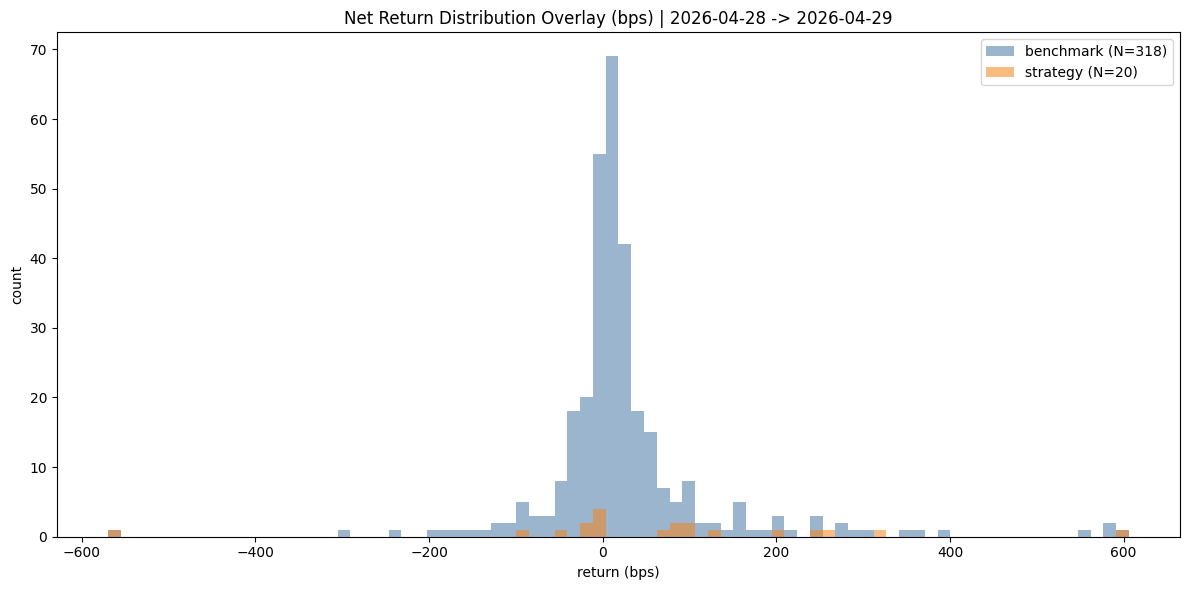

In [31]:
# One-figure overlay distribution
bench_bps = pd.to_numeric(bench_detail["full_net"], errors="coerce") * 10000.0
strat_bps = pd.to_numeric(strat_detail["full_net"], errors="coerce") * 10000.0

plt.figure(figsize=(12, 6))
plt.hist(bench_bps.dropna(), bins=80, alpha=0.55, label=f"benchmark (N={len(bench_bps.dropna())})", color="#4C78A8")
plt.hist(strat_bps.dropna(), bins=80, alpha=0.55, label=f"strategy (N={len(strat_bps.dropna())})", color="#F58518")
plt.title(f"Net Return Distribution Overlay (bps) | {trade_day} -> {next_day}")
plt.xlabel("return (bps)")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
print("Benchmark detail top/bottom by full_net:")
display(bench_detail[["code", "full_gross", "full_net", "cost_drag"]].sort_values("full_net", ascending=False).head(TOP_N))
display(bench_detail[["code", "full_gross", "full_net", "cost_drag"]].sort_values("full_net", ascending=True).head(TOP_N))

print("Strategy detail top/bottom by full_net:")
show_cols = ["code", "weight", "full_gross", "full_net", "cost_drag"]
show_cols = [c for c in show_cols if c in strat_detail.columns]
display(strat_detail[show_cols].sort_values("full_net", ascending=False).head(TOP_N))
display(strat_detail[show_cols].sort_values("full_net", ascending=True).head(TOP_N))


Benchmark detail top/bottom by full_net:


,code,full_gross,full_net,cost_drag
19,111001.SH,0.060851,0.060618,-0.000233
180,123131.SZ,0.058523,0.058290,-0.000233
293,127095.SZ,0.058009,0.057776,-0.000233
55,113589.SH,0.056073,0.055841,-0.000232
135,118041.SH,0.039849,0.039620,-0.000229
23,111005.SH,0.036974,0.036746,-0.000228
18,111000.SH,0.035506,0.035278,-0.000228
298,127103.SZ,0.030980,0.030753,-0.000227
302,127109.SZ,0.029720,0.029494,-0.000227
240,123259.SZ,0.028375,0.028148,-0.000226


,code,full_gross,full_net,cost_drag
128,118033.SH,-0.056777,-0.056984,-0.000207
192,123160.SZ,-0.030308,-0.030521,-0.000213
124,118027.SH,-0.023720,-0.023934,-0.000215
268,127055.SZ,-0.018590,-0.018806,-0.000216
294,127096.SZ,-0.017336,-0.017553,-0.000216
249,127024.SZ,-0.017027,-0.017243,-0.000216
5,110081.SH,-0.014146,-0.014363,-0.000217
137,118044.SH,-0.013472,-0.013689,-0.000217
82,113659.SH,-0.012316,-0.012533,-0.000217
90,113673.SH,-0.011270,-0.011488,-0.000217


Strategy detail top/bottom by full_net:


,code,weight,full_gross,full_net,cost_drag
6,111001.SH,0.05,0.060851,0.060618,-0.000233
11,113618.SH,0.05,0.032604,0.032377,-0.000227
13,123256.SZ,0.05,0.025733,0.025507,-0.000226
2,123241.SZ,0.05,0.024141,0.023916,-0.000225
10,113039.SH,0.05,0.020512,0.020288,-0.000224
15,123255.SZ,0.05,0.013168,0.012945,-0.000223
1,113677.SH,0.05,0.010581,0.010359,-0.000222
7,123247.SZ,0.05,0.010154,0.009932,-0.000222
5,127037.SZ,0.05,0.008860,0.008638,-0.000222
16,123176.SZ,0.05,0.008273,0.008051,-0.000222


,code,weight,full_gross,full_net,cost_drag
14,118033.SH,0.05,-0.056777,-0.056984,-0.000207
17,118004.SH,0.05,-0.009202,-0.009420,-0.000218
3,113615.SH,0.05,-0.003876,-0.004095,-0.000219
8,118030.SH,0.05,-0.002337,-0.002556,-0.000219
18,123258.SZ,0.05,-0.001530,-0.001750,-0.000220
9,118058.SH,0.05,-0.000887,-0.001107,-0.000220
19,113616.SH,0.05,-0.000720,-0.000940,-0.000220
4,123243.SZ,0.05,-0.000619,-0.000839,-0.000220
12,123158.SZ,0.05,0.000551,0.000331,-0.000220
0,127070.SZ,0.05,0.007704,0.007483,-0.000222


In [33]:
if EXPORT_CSV:
    out_dir = PROJECT_ROOT / "notebook" / "outputs"
    out_dir.mkdir(parents=True, exist_ok=True)

    bench_detail.to_csv(out_dir / f"benchmark_detail_{trade_day:%Y%m%d}.csv", index=False, encoding="utf-8-sig")
    bench_disabled.to_csv(out_dir / f"benchmark_disabled_{trade_day:%Y%m%d}.csv", index=False, encoding="utf-8-sig")
    strat_detail.to_csv(out_dir / f"strategy_detail_{trade_day:%Y%m%d}.csv", index=False, encoding="utf-8-sig")
    strat_disabled.to_csv(out_dir / f"strategy_disabled_{trade_day:%Y%m%d}.csv", index=False, encoding="utf-8-sig")
    summary_df.to_csv(out_dir / f"summary_{trade_day:%Y%m%d}.csv", index=False, encoding="utf-8-sig")

    print(f"saved outputs to: {out_dir}")
